In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
actual = pd.read_csv('data/actual.csv')
test_df = pd.read_csv('data/data_set_ALL_AML_independent.csv')
train_df = pd.read_csv('data/data_set_ALL_AML_train.csv')

In [3]:
df1 = [col for col in train_df.columns if "call" not in col]
train_df = train_df[df1]
train_df.T.head(7)

,0,1,2,3,4,5,6,7,8,9,...,7119,7120,7121,7122,7123,7124,7125,7126,7127,7128
Gene Description,AFFX-BioB-5_at (endogenous control),AFFX-BioB-M_at (endogenous control),AFFX-BioB-3_at (endogenous control),AFFX-BioC-5_at (endogenous control),AFFX-BioC-3_at (endogenous control),AFFX-BioDn-5_at (endogenous control),AFFX-BioDn-3_at (endogenous control),AFFX-CreX-5_at (endogenous control),AFFX-CreX-3_at (endogenous control),AFFX-BioB-5_st (endogenous control),...,Transcription factor Stat5b (stat5b) mRNA,Breast epithelial antigen BA46 mRNA,GB DEF = Calcium/calmodulin-dependent protein ...,TUBULIN ALPHA-4 CHAIN,CYP4B1 Cytochrome P450; subfamily IVB; polypep...,PTGER3 Prostaglandin E receptor 3 (subtype EP3...,HMG2 High-mobility group (nonhistone chromosom...,RB1 Retinoblastoma 1 (including osteosarcoma),GB DEF = Glycophorin Sta (type A) exons 3 and ...,GB DEF = mRNA (clone 1A7)
Gene Accession Number,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
1,-214,-153,-58,88,-295,-558,199,-176,252,206,...,185,511,-125,389,-37,793,329,36,191,-37
2,-139,-73,-1,283,-264,-400,-330,-168,101,74,...,169,837,-36,442,-17,782,295,11,76,-14
3,-76,-49,-307,309,-376,-650,33,-367,206,-215,...,315,1199,33,168,52,1138,777,41,228,-41
4,-135,-114,265,12,-419,-585,158,-253,49,31,...,240,835,218,174,-110,627,170,-50,126,-91
5,-106,-125,-76,168,-230,-284,4,-122,70,252,...,156,649,57,504,-26,250,314,14,56,-25


In [4]:
train_df = train_df.T
train_df2 = train_df.drop(['Gene Description','Gene Accession Number'],axis=0)
train_df2.index = pd.to_numeric(train_df2.index)
train_df2.sort_index(inplace=True)
train_df2.head()

,0,1,2,3,4,5,6,7,8,9,...,7119,7120,7121,7122,7123,7124,7125,7126,7127,7128
1,-214,-153,-58,88,-295,-558,199,-176,252,206,...,185,511,-125,389,-37,793,329,36,191,-37
2,-139,-73,-1,283,-264,-400,-330,-168,101,74,...,169,837,-36,442,-17,782,295,11,76,-14
3,-76,-49,-307,309,-376,-650,33,-367,206,-215,...,315,1199,33,168,52,1138,777,41,228,-41
4,-135,-114,265,12,-419,-585,158,-253,49,31,...,240,835,218,174,-110,627,170,-50,126,-91
5,-106,-125,-76,168,-230,-284,4,-122,70,252,...,156,649,57,504,-26,250,314,14,56,-25


In [5]:
train_df2['cancer_type'] = list(pd.read_csv('data/actual.csv')[:38]['cancer'])
dic = {'ALL':0,'AML':1}
train_df2.replace(dic,inplace=True)
train_df2.head(5)

/tmp/ipykernel_5173/1198820567.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df2.replace(dic,inplace=True)


,0,1,2,3,4,5,6,7,8,9,...,7120,7121,7122,7123,7124,7125,7126,7127,7128,cancer_type
1,-214,-153,-58,88,-295,-558,199,-176,252,206,...,511,-125,389,-37,793,329,36,191,-37,0
2,-139,-73,-1,283,-264,-400,-330,-168,101,74,...,837,-36,442,-17,782,295,11,76,-14,0
3,-76,-49,-307,309,-376,-650,33,-367,206,-215,...,1199,33,168,52,1138,777,41,228,-41,0
4,-135,-114,265,12,-419,-585,158,-253,49,31,...,835,218,174,-110,627,170,-50,126,-91,0
5,-106,-125,-76,168,-230,-284,4,-122,70,252,...,649,57,504,-26,250,314,14,56,-25,0


PCA

In [21]:
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(train_df2.drop('cancer_type',axis=1))

from sklearn.decomposition import PCA as sklearnPCA
sklearn_pca = sklearnPCA(n_components=38)
Y_sklearn = sklearn_pca.fit_transform(X_std)
print(sklearn_pca.components_.shape)
print(sklearn_pca.components_)

(38, 7129)
[[-1.29741138e-02 -6.48473527e-03  1.86511421e-03 ...  7.14956201e-03
   3.55688572e-03 -5.95097737e-05]
 [-2.17619942e-03 -4.86244308e-03 -3.56293818e-03 ...  1.57028822e-02
  -8.27612611e-03 -4.76305008e-03]
 [ 7.17359328e-03  7.91294911e-03  1.59078930e-03 ... -7.21514208e-03
   1.96830386e-02  7.56848583e-03]
 ...
 [-4.30269582e-03 -9.37003384e-03  1.21214791e-02 ...  8.93968747e-04
   2.59520162e-03  5.64681769e-03]
 [ 1.33206156e-03 -7.42790107e-04  7.57589073e-03 ...  1.28933023e-03
  -2.12866137e-02 -1.90438750e-02]
 [-9.41920528e-02 -1.76334621e-02  4.67042702e-03 ...  2.32858205e-03
   1.18246940e-03 -5.36272316e-04]]


explained variance for the first 3 components: 0.3356617215830922
explained variance for the first 5 components: 0.43083509470846304


Text(0.5, 1.0, 'Around 95% of variance is explained by the First 30 colmns ')

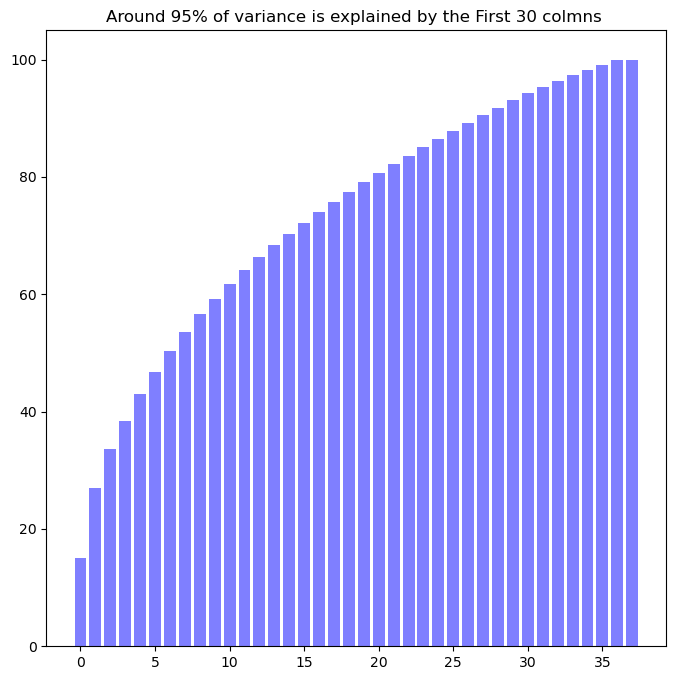

In [22]:
cum_sum = sklearn_pca.explained_variance_ratio_.cumsum()

sklearn_pca.explained_variance_ratio_[:10].sum()
print('explained variance for the first 3 components:',sklearn_pca.explained_variance_ratio_[:3].sum())
print('explained variance for the first 5 components:',sklearn_pca.explained_variance_ratio_[:5].sum())

cum_sum = cum_sum*100

fig, ax = plt.subplots(figsize=(8,8))
plt.bar(range(38), cum_sum, label='Cumulative _Sum_of_Explained _Variance', color = 'b',alpha=0.5)
plt.title("Around 95% of variance is explained by the First 30 colmns ")

In [8]:
X_reduced2 = Y_sklearn
train_df2.cancer_type.values
train = pd.DataFrame(X_reduced2)
train['cancer_type'] =  train_df2['cancer_type'].reset_index().cancer_type
train.head(3)

,0,1,2,3,4,5,6,7,8,9,...,29,30,31,32,33,34,35,36,37,cancer_type
0,18.544799,5.826943,-19.442313,-11.267566,5.303304,19.100937,-9.447438,0.915309,-8.665217,-7.912754,...,12.217094,4.453306,3.547129,-4.069730,4.971902,4.917972,-3.149796,-0.519943,3.578679e-14,0
1,-7.341389,10.008663,11.795698,3.920823,-13.999094,-18.636026,4.687060,8.812418,1.372678,-11.690751,...,-1.015588,-16.729140,-0.297116,-1.281421,0.059577,1.335076,3.917413,-0.234563,3.578679e-14,0
2,52.852146,11.390630,-29.548566,-38.800348,-22.866689,-9.458113,-22.880735,20.995112,4.038731,-5.260765,...,7.354274,-2.709089,4.263477,-1.044389,-4.758257,0.476333,-3.087929,3.614202,3.578679e-14,0


Text(0.5, 1.0, '2D Transformation ')

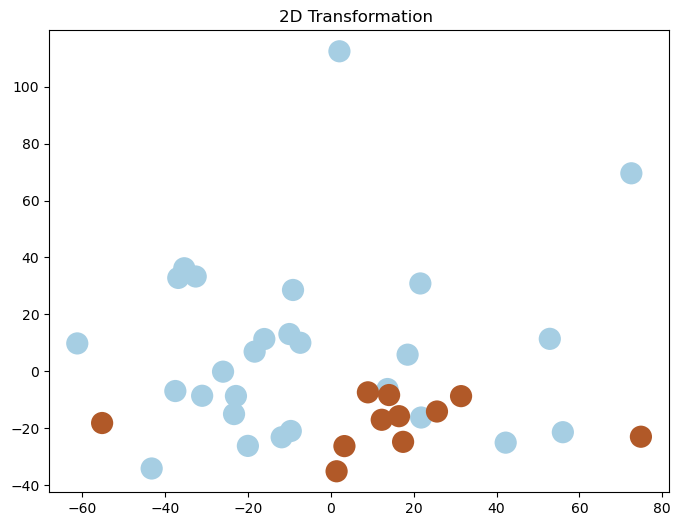

In [24]:
sklearn_pca = sklearnPCA(n_components=3)
X_reduced  = sklearn_pca.fit_transform(X_std)
fig = plt.figure(1, figsize=(8,6))
plt.scatter(X_reduced[:, 0],  X_reduced[:, 1], c=train_df2['cancer_type'],cmap=plt.cm.Paired,linewidths=10)

#plt.scatter(test_reduced[:, 0],  test_reduced[:, 1],c='r')
plt.title("2D Transformation ")

Sparse PCA

In [29]:
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(train_df2.drop('cancer_type',axis=1))

from sklearn.decomposition import SparsePCA
spca_3 = SparsePCA(n_components=3, alpha=1)
Y_spca_3 = spca_3.fit(X_std)

In [30]:
X_transformed = Y_spca_3.transform(X_std)
print(spca_3.components_.shape)
print(spca_3.components_)
print('percentage of 0 values:',np.mean(spca_3.components_ == 0))

(3, 7129)
[[-0.01248582 -0.00312775  0.         ...  0.00224392  0.
   0.        ]
 [ 0.          0.          0.         ...  0.01555898 -0.0035393
   0.        ]
 [ 0.          0.          0.         ...  0.          0.01676546
   0.        ]]
percentage of 0 values: 0.42100341328844626


In [13]:
X_reconstructed = X_transformed @ spca_3.components_
total_var = np.var(X_std, axis=0).sum()
explained_var = np.var(X_reconstructed, axis=0).sum()
explained_ratio = explained_var / total_var

print("approximated explained variance ratio for 3 components:", explained_ratio)

approximated explained variance ratio for 3 components: 0.30020285765149585


In [14]:
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(train_df2.drop('cancer_type',axis=1))

from sklearn.decomposition import SparsePCA
spca_5 = SparsePCA(n_components=5, alpha=1)
Y_spca_5 = spca_5.fit(X_std)

In [15]:
print(spca_5.components_.shape)
print(spca_5.components_)
print('percentage of 0 values:',np.mean(spca_5.components_ == 0))

(5, 7129)
[[ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.00543153  0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.01709379
   0.        ]
 [-0.03296134 -0.01129354 -0.         ...  0.00286871 -0.
  -0.        ]
 [ 0.          0.00147779  0.         ...  0.02864336 -0.01698139
   0.        ]]
percentage of 0 values: 0.5015850750455885


In [16]:
X_transformed = Y_spca_5.transform(X_std)
X_reconstructed = X_transformed @ spca_5.components_
total_var = np.var(X_std, axis=0).sum()
explained_var = np.var(X_reconstructed, axis=0).sum()
explained_ratio = explained_var / total_var

print("approximated explained variance ratio for 5 components:", explained_ratio)

approximated explained variance ratio for 5 components: 0.36939097155752837


In [17]:
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(train_df2.drop('cancer_type',axis=1))

from sklearn.decomposition import SparsePCA
spca_10 = SparsePCA(n_components=10, alpha=1)
Y_spca_10 = spca_10.fit(X_std)

In [18]:
print(spca_10.components_.shape)
print(spca_10.components_)
print('percentage of 0 values:',np.mean(spca_10.components_ == 0))

(10, 7129)
[[ 0.          0.         -0.00220775 ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.00800352 -0.00375799
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 ...
 [-0.03532831 -0.02940928 -0.01542394 ...  0.          0.
   0.00554574]
 [ 0.         -0.0010273   0.         ...  0.          0.
   0.        ]
 [-0.00317891  0.          0.         ...  0.01430053  0.
   0.        ]]
percentage of 0 values: 0.6051199326693786


In [19]:
X_transformed = Y_spca_10.transform(X_std)
X_reconstructed = X_transformed @ spca_10.components_
total_var = np.var(X_std, axis=0).sum()
explained_var = np.var(X_reconstructed, axis=0).sum()
explained_ratio = explained_var / total_var

print("approximated explained variance ratio for 10 components:", explained_ratio)

approximated explained variance ratio for 10 components: 0.47860346705279977


Text(0.5, 1.0, '2D Transformation ')

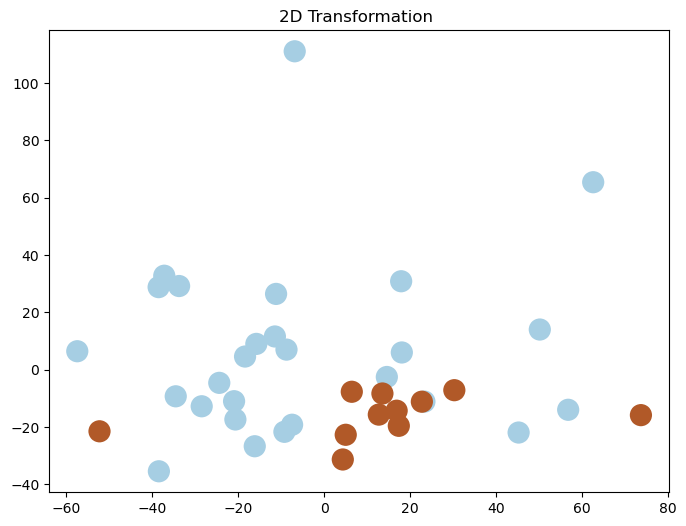

In [26]:
spca_2 = SparsePCA(n_components=2, alpha=1)
X_reduced  = spca_2.fit_transform(X_std)
fig = plt.figure(1, figsize=(8,6))
plt.scatter(X_reduced[:, 0],  X_reduced[:, 1], c=train_df2['cancer_type'],cmap=plt.cm.Paired,linewidths=10)

#plt.scatter(test_reduced[:, 0],  test_reduced[:, 1],c='r')
plt.title("2D Transformation ")